# Comparing HFO event types and recording modality across Omni-iEEG

Split out of `raw_data_visualization.ipynb`: that notebook is a deep dive on
one example recording; this one scans every processed recording for
doctor-annotated HFO events and compares waveforms across event types and
recording technologies. Self-contained -- only depends on the processed
`.h5` files, not on the single-recording exploration above.

In [1]:
import os
from typing import Any
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import resample, spectrogram
from torch_brain.data import Data

In [2]:
BIDS_ROOT = "/capstor/scratch/cscs/davalos/data/processed/omni_ieeg"

In [ ]:

# (A) The time-domain augmentation consisted of two steps: 
#   (1) random time-domain shift, the window of selecting EEG tracing to generate feature (initially center at the middle of the HFO with ±285 ms around it) could be randomly shifted ±50 ms in the time domain
#   (2) the EEG signal was randomly flipped in the time domain
# see: pyHFO/src/hfo_feature.py

PREPROCESS = dict(
    freq_range_hz=[10, 500],
    fs=2000,
    image_size=224, # Crop applied to the cached 224x224 images
    random_shift_ms=50,
    selected_freq_range_hz=[10, 220], # 220 for artifact, spike, 500 for eHFO
    selected_window_size_ms=285,
    time_range_ms=[0, 1000],
    event_length=1000,
)

In [31]:
def get_event_waveform(
    signal: np.ndarray,
    timestamps: np.ndarray,
    channel_idx: int,
    event_start_s: float,
    event_end_s: float,
    preprocess: dict[str, Any] = PREPROCESS,
) -> np.ndarray:
    """Extract the event_length ms window centered on an HFO event and resample it to fs Hz, matching PyHFO's own extraction (extract_waveforms + concate_edf(..., resample=...) in Omni-iEEG)."""

    center_s = 0.5 * (event_start_s + event_end_s)
    half_len_s = preprocess["time_range_ms"][1] / 1000 / 2 # ms to s
    keep = (timestamps >= center_s - half_len_s) & (timestamps < center_s + half_len_s)
    trace = signal[keep, channel_idx].astype(np.float64)
    n_target = int(preprocess["time_range_ms"][1] / 1000 * preprocess["fs"])
    return resample(trace, n_target)

### Comparing HFO event types and recording modality

Compares annotated HFO events across:
- **event type**: artifact (doctor-flagged false positive), spHFO (co-occurs with a spike), isolated HFO,
- **recording technology**: ECoG vs SEEG (`device.recording_tech`).

Events might differ hugely in raw amplitude across patients/channels/modalities, so plotting many raw waveforms superposed on one axis mostly produces unreadable clutter. This notebook uses **small multiples** (a grid, one panel per event) as the default view for browsing many examples, and a separate **normalized overlay** (each waveform z-scored, plotted at low alpha, with the group mean in bold) as the "superposed" view for comparing average shape across a group, normalizing is what makes that superposition actually legible.


In [8]:
def scan_annotated_recordings(bids_root: str) -> pd.DataFrame:
    """List every recording under `bids_root` with its HFO-annotation count, recording technology, and dataset.
    Read directly via h5py so this stays cheap even as more (mostly un-annotated) recordings are added.

    `channel`/`detector`/`artifact`/`spike` are only present on `annotations`
    once doctor-labeled HFO events were actually merged in (see `_build_annotations` in omni_ieeg.py),
    a recording with only raw MNE-embedded annotations (no HFO merge) has none of those fields, so
    counting any non-zero `annotations/start` here would wrongly flag it as
    HFO-annotated and crash `collect_hfo_examples` downstream on ann.channel.
    """
    rows = []
    for fname in sorted(os.listdir(bids_root)):
        if not fname.endswith(".h5"):
            continue
        with h5py.File(os.path.join(bids_root, fname), "r") as f:
            ann = f["annotations"]
            if "channel" in ann:
                channels = ann["channel"].asstr()[:]
                n_ann = int((channels != "").sum())
            else:
                n_ann = 0
            rows.append(
                dict(
                    file=fname,
                    n_annotations=n_ann,
                    recording_tech=f["device"].attrs.get("recording_tech"),
                    dataset_name=f.attrs.get("dataset_name"),
                    fs=f["ieeg"].attrs.get("sampling_rate"),
                )
            )
    return pd.DataFrame(rows)

In [14]:
recordings = scan_annotated_recordings(BIDS_ROOT)

In [27]:
recordings.sort_values(by=["n_annotations"], ascending=False, inplace=True)
recordings

,file,n_annotations,recording_tech,dataset_name,fs
473,sub-openieegUCLA10_ses-01_task-sleep.h5,2921,ECoG,openieeg,2000.0
480,sub-openieegUCLA17_ses-01_task-sleep.h5,1920,ECoG,openieeg,2000.0
408,sub-openieegDetroit002_ses-01_task-sleep.h5,1891,ECoG,openieeg,1000.0
407,sub-openieegDetroit001_ses-01_task-sleep.h5,1532,ECoG,openieeg,1000.0
411,sub-openieegDetroit005_ses-01_task-sleep.h5,1507,ECoG,openieeg,1000.0
...,...,...,...,...,...
198,sub-hupHUP117_ses-01_task-interictal_run-01.h5,0,SEEG,hup,500.0
199,sub-hupHUP117_ses-01_task-interictal_run-02.h5,0,SEEG,hup,500.0
192,sub-hupHUP116_ses-01_task-ictal_run-03.h5,0,SEEG,hup,500.0
194,sub-hupHUP116_ses-01_task-interictal_run-02.h5,0,SEEG,hup,500.0


In [28]:
print("\nannotated events per recording technology:")
print(recordings.groupby("recording_tech")["n_annotations"].sum())


annotated events per recording technology:
recording_tech
ECOG        0
ECoG    20260
MISC        0
SEEG        0
Name: n_annotations, dtype: int64


In [32]:
def collect_hfo_examples(
    bids_root: str,
    recordings: pd.DataFrame,
    max_events_per_type: int = 15,
    preprocess: dict[str, Any] = PREPROCESS,
) -> list[dict[str, Any]]:
    """Extract up to `max_events_per_type` annotated HFO waveforms per
    (recording, event_type), sampled per type rather than uniformly over all
    events
    artifacts are rare (~1% here), so a blind uniform subsample would silently drop them from the comparison."""
    
    examples = []
    annotated = recordings[recordings["n_annotations"] > 0]
    for _, row in annotated.iterrows():
        with h5py.File(os.path.join(bids_root, row["file"]), "r") as f:
            file_data = Data.from_hdf5(f, lazy=False)
        ch_names = file_data.channels.id.astype(str)
        sig = file_data.ieeg.signal
        ts = file_data.ieeg.timestamps
        ann = file_data.annotations
        ann_channel = ann.channel.astype(str)
        ann_detector = ann.detector.astype(str)

        event_types = np.where(
            np.asarray(ann.artifact) == 1,
            "artifact",
            np.where(np.asarray(ann.spike) == 1, "spHFO", "isolated HFO"),
        )
        for event_type in np.unique(event_types):
            type_idx = np.where(event_types == event_type)[0]
            sample_idx = type_idx[np.linspace(0, len(type_idx) - 1, min(len(type_idx), max_events_per_type)).astype(int)]
            print(f"{row['file']}: sampling {len(sample_idx)}/{len(type_idx)} '{event_type}' events")

            for i in sample_idx:
                ch_idx = np.where(ch_names == ann_channel[i])[0]
                if len(ch_idx) == 0:
                    continue
                waveform = get_event_waveform(sig, ts, ch_idx[0], ann.start[i], ann.end[i], preprocess)
                examples.append(
                    dict(
                        file=row["file"],
                        recording_tech=row["recording_tech"],
                        dataset_name=row["dataset_name"],
                        channel=ann_channel[i],
                        detector=ann_detector[i],
                        event_type=event_type,
                        waveform=waveform,
                    )
                )
    return examples

In [33]:
examples = collect_hfo_examples(BIDS_ROOT, recordings, max_events_per_type=15)
print(f"\ncollected {len(examples)} example events total")

sub-openieegUCLA10_ses-01_task-sleep.h5: sampling 15/2764 'artifact' events
sub-openieegUCLA10_ses-01_task-sleep.h5: sampling 15/157 'isolated HFO' events
sub-openieegUCLA17_ses-01_task-sleep.h5: sampling 15/1784 'artifact' events
sub-openieegUCLA17_ses-01_task-sleep.h5: sampling 15/136 'isolated HFO' events
sub-openieegDetroit002_ses-01_task-sleep.h5: sampling 15/1759 'artifact' events
sub-openieegDetroit002_ses-01_task-sleep.h5: sampling 15/132 'isolated HFO' events
sub-openieegDetroit001_ses-01_task-sleep.h5: sampling 15/164 'artifact' events
sub-openieegDetroit001_ses-01_task-sleep.h5: sampling 15/1368 'isolated HFO' events
sub-openieegDetroit005_ses-01_task-sleep.h5: sampling 15/1378 'artifact' events
sub-openieegDetroit005_ses-01_task-sleep.h5: sampling 15/129 'isolated HFO' events
sub-openieegUCLA16_ses-01_task-sleep.h5: sampling 15/1116 'artifact' events
sub-openieegUCLA16_ses-01_task-sleep.h5: sampling 15/95 'isolated HFO' events
sub-openieegUCLA07_ses-01_task-sleep.h5: sampli

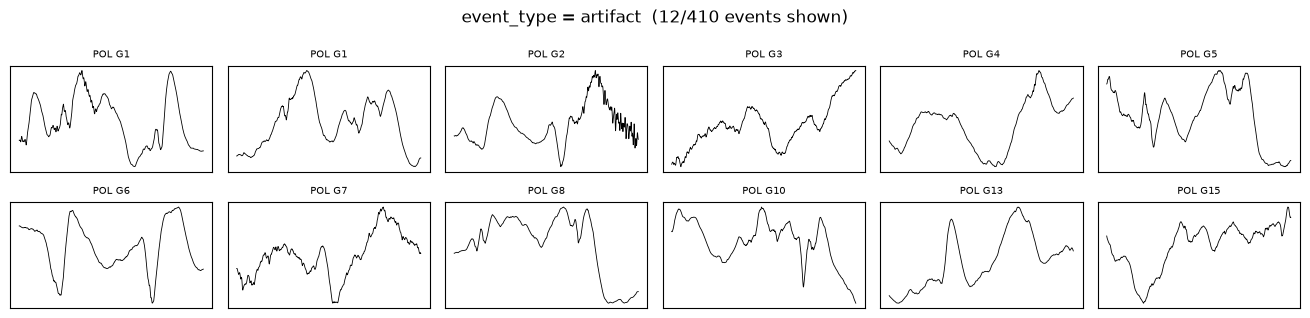

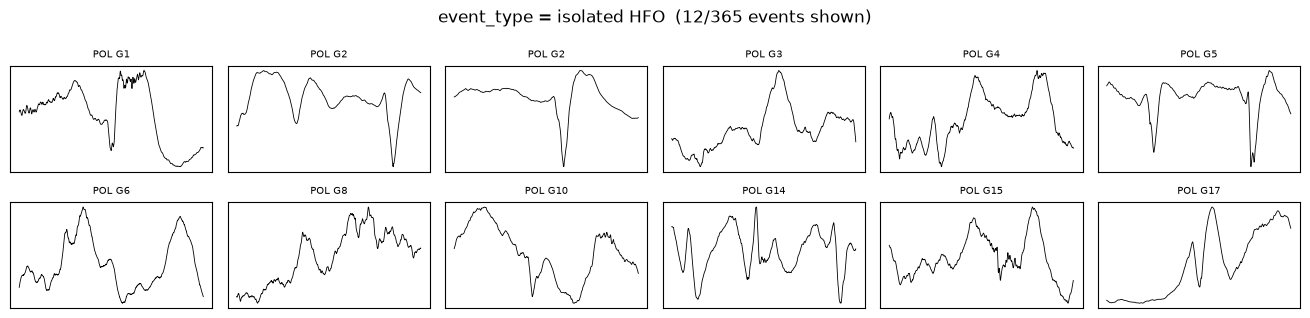

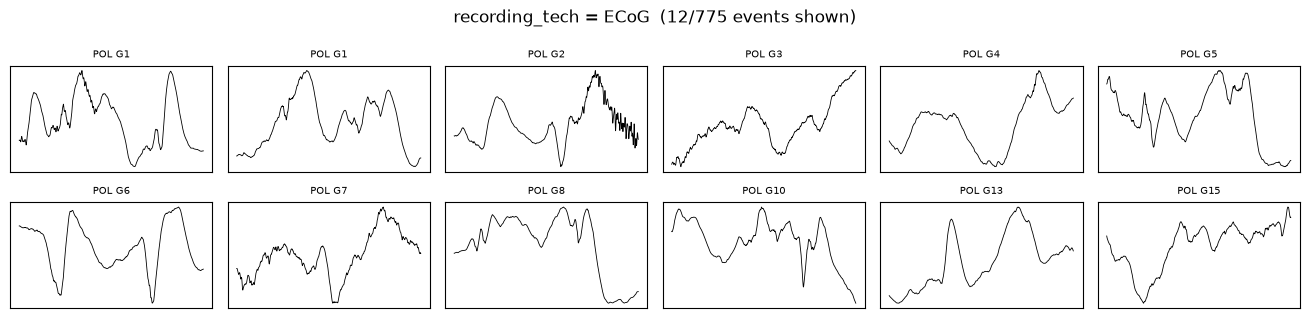

In [34]:
def plot_event_grid(
    examples: list[dict[str, Any]],
    group_key: str,
    n_per_group: int = 12,
    ncols: int = 6,
    preprocess: dict[str, Any] = PREPROCESS,
) -> None:
    """Small multiples of raw waveforms, one panel per event, grouped by
    `group_key` (e.g. "event_type", "recording_tech"). Always prints how many
    events exist per group vs. how many are actually plotted."""
    groups: dict[Any, list[dict[str, Any]]] = {}
    for ex in examples:
        groups.setdefault(ex[group_key], []).append(ex)

    for group_name, group_examples in groups.items():
        shown = group_examples[:n_per_group]
        t_ms = np.linspace(0, preprocess["event_length"], len(shown[0]["waveform"]))
        nrows = int(np.ceil(len(shown) / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(2.2 * ncols, 1.6 * nrows), sharex=True)
        axes = np.atleast_1d(axes).ravel()
        for ax, ex in zip(axes, shown):
            ax.plot(t_ms, ex["waveform"], color="black", linewidth=0.6)
            ax.set_title(ex["channel"], fontsize=7)
            ax.set_xticks([])
            ax.set_yticks([])
        for ax in axes[len(shown):]:
            ax.axis("off")
        fig.suptitle(f"{group_key} = {group_name}  ({len(shown)}/{len(group_examples)} events shown)")
        fig.tight_layout()
        fig.show()


plot_event_grid(examples, group_key="event_type")
plot_event_grid(examples, group_key="recording_tech")

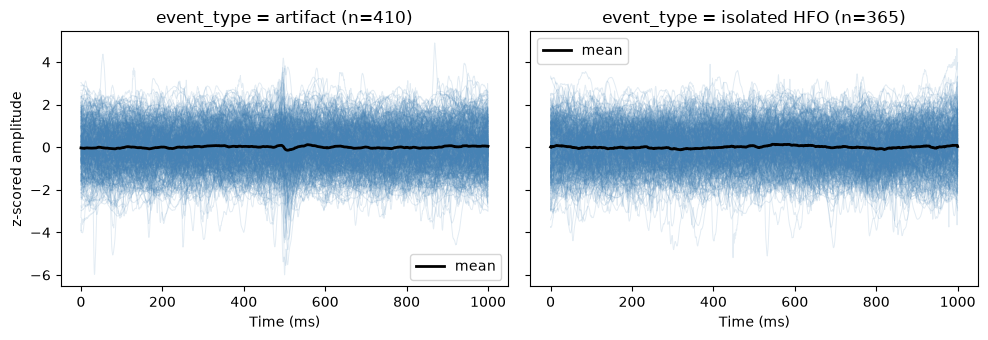

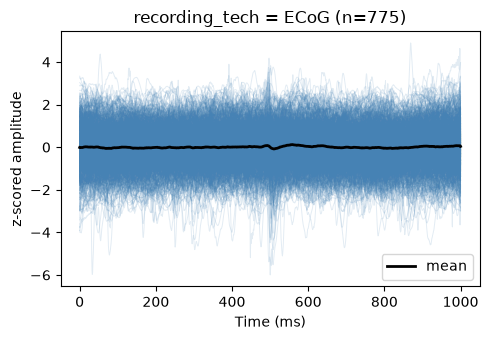

In [35]:
def plot_group_overlay(
    examples: list[dict[str, Any]],
    group_key: str,
    preprocess: dict[str, Any] = PREPROCESS,
) -> plt.Figure:
    """Normalized (z-scored) overlay of every event's waveform per group, with
    the group mean in bold -- a superposition view that stays legible across
    events of very different raw amplitude."""
    groups: dict[Any, list[dict[str, Any]]] = {}
    for ex in examples:
        groups.setdefault(ex[group_key], []).append(ex)

    fig, axes = plt.subplots(1, len(groups), figsize=(5 * len(groups), 3.5), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, (group_name, group_examples) in zip(axes, groups.items()):
        traces = np.stack(
            [
                (ex["waveform"] - ex["waveform"].mean()) / (ex["waveform"].std() + 1e-9)
                for ex in group_examples
            ]
        )
        t_ms = np.linspace(0, preprocess["event_length"], traces.shape[1])
        ax.plot(t_ms, traces.T, color="steelblue", alpha=0.15, linewidth=0.7)
        ax.plot(t_ms, traces.mean(axis=0), color="black", linewidth=2, label="mean")
        ax.set_title(f"{group_key} = {group_name} (n={len(group_examples)})")
        ax.set_xlabel("Time (ms)")
        ax.legend()
    axes[0].set_ylabel("z-scored amplitude")
    fig.tight_layout()
    return fig


fig = plot_group_overlay(examples, group_key="event_type")
fig.show()
fig = plot_group_overlay(examples, group_key="recording_tech")
fig.show()

`plot_group_overlay`'s waveform view above superposes normalized traces --
that works because 1-D lines can be plotted on top of each other. A
spectrogram is a 2-D time-frequency image, so "overlay" instead means the
**grand-average spectrogram** per group: the element-wise mean power across
every event's spectrogram, shown as one panel per group on a shared color
scale so magnitudes stay comparable across groups.

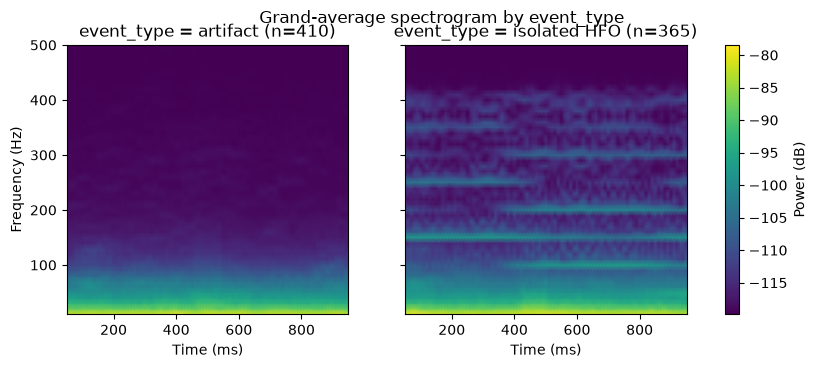

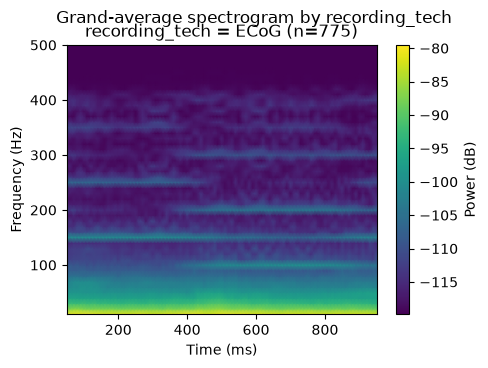

In [36]:
def get_event_spectrogram(
    waveform: np.ndarray,
    preprocess: dict[str, Any] = PREPROCESS,
    window_ms: float = 100,
    step_ms: float = 10,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Spectrogram of one resampled event waveform, restricted to `freq_range_hz`.

    Uses a much shorter window than the ~600ms one used for continuous-signal
    spectrograms in raw_data_visualization.ipynb, since an event here is only
    `event_length` ms (1000 ms by default) -- `window_ms`/`step_ms` control
    the same frequency/time resolution trade-off, just scaled down.
    """
    fs = preprocess["fs"]
    nperseg = min(len(waveform), int(window_ms / 1000 * fs))
    noverlap = nperseg - max(1, int(step_ms / 1000 * fs))
    freqs, times, sxx = spectrogram(waveform, fs=fs, nperseg=nperseg, noverlap=noverlap)
    low, high = preprocess["freq_range_hz"]
    keep = (freqs >= low) & (freqs <= high)
    return freqs[keep], times, sxx[keep]


def plot_group_spectrogram_overlay(
    examples: list[dict[str, Any]],
    group_key: str,
    preprocess: dict[str, Any] = PREPROCESS,
) -> plt.Figure:
    """Grand-average spectrogram per group -- the spectrogram analogue of
    `plot_group_overlay` (see markdown above for why "overlay" means
    averaging here rather than superposing)."""
    groups: dict[Any, list[dict[str, Any]]] = {}
    for ex in examples:
        groups.setdefault(ex[group_key], []).append(ex)

    freqs = times = None
    group_means: dict[Any, np.ndarray] = {}
    for group_name, group_examples in groups.items():
        specs = []
        for ex in group_examples:
            freqs, times, sxx = get_event_spectrogram(ex["waveform"], preprocess)
            specs.append(sxx)
        group_means[group_name] = np.mean(np.stack(specs), axis=0)

    db_means = {name: 10 * np.log10(m + 1e-12) for name, m in group_means.items()}
    vmin = min(m.min() for m in db_means.values())
    vmax = max(m.max() for m in db_means.values())

    fig, axes = plt.subplots(1, len(groups), figsize=(5 * len(groups), 3.5), sharey=True)
    axes = np.atleast_1d(axes)
    mesh = None
    for ax, (group_name, db_sxx) in zip(axes, db_means.items()):
        mesh = ax.pcolormesh(
            times * 1000, freqs, db_sxx, shading="gouraud", vmin=vmin, vmax=vmax
        )
        ax.set_title(f"{group_key} = {group_name} (n={len(groups[group_name])})")
        ax.set_xlabel("Time (ms)")
    axes[0].set_ylabel("Frequency (Hz)")
    fig.colorbar(mesh, ax=list(axes), label="Power (dB)")
    fig.suptitle(f"Grand-average spectrogram by {group_key}")
    return fig


fig = plot_group_spectrogram_overlay(examples, group_key="event_type")
fig.show()
fig = plot_group_spectrogram_overlay(examples, group_key="recording_tech")
fig.show()

In [ ]:
def get_spectral_data(
    signal: np.ndarray,
    timestamps: np.ndarray,
    channel_idx: int = 0,
    start_time: int = 0,
    end_time: int = None,
    window_ms: int = 600,
    step_ms: int = 300,
):
    if end_time is None:
        end_time = timestamps[-1]
    keep = (timestamps >= start_time) & (timestamps <= end_time)
    trace = signal[keep, channel_idx]
    t = timestamps[keep]

    sfreq = 1 / np.median(np.diff(t))
    nperseg = int(window_ms / 1000 * sfreq)
    noverlap = nperseg - int(step_ms / 1000 * sfreq)

    freqs, times, sxx = spectrogram(
        trace, fs=sfreq, nperseg=nperseg, noverlap=noverlap
    )
    return t, freqs, times, sxx

In [ ]:
def plot_spectrogram(t, freqs, times, sxx, channel_idx, figsize):
    # TODO add type hints
    fig, ax = plt.subplots(figsize=figsize)
    mesh = ax.pcolormesh(
        t[0] + times, freqs, 10 * np.log10(sxx + 1e-12), shading="gouraud"
    )
    fig.colorbar(mesh, ax=ax, label="Power (dB)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency (Hz)")
    ax.set_title(
        f"{ch_names[channel_idx]} ({ch_types[channel_idx]}) spectrogram"
    )
    fig.tight_layout()
    return fig